#Setup

In [1]:
#install python packages
!pip3 install -q folium scikit-learn census seaborn geopandas us openpyxl python-calamine
%pdb off


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Automatic pdb calling has been turned OFF


In [2]:
#load python packages
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
import os
import us
import math
import requests
import openpyxl
import pdb
%pdb on

Automatic pdb calling has been turned ON


# **Exploring Ballot Utilization Rates in Ranked Choice Voting Elections in US Cities**


#Introduction

#Literature Review


##Single Seat vs. Multi Seat RCV
* Explain the difference between NYC and Portland's elections

## Ballot "Utility" vs. "Futility"
- What are the common ways of measuring ballot error and why are they concerning?
- How does each state deal with invalid votes?

##Theory on RCV and Representation
- Why people would think RCV is good for minority representation
- Briefly mention other benefits of RCV for minority representation (e.g. candidate selection, changing campaign incentives)
- Why people would think RCV is bad for minority representation (set up discussion of different ballot errors)

#Data Cleaning

## New York, NY

### Load the NYC election district shapefiles

In [3]:
#load NYC election districts
nyc_ED_gdf = gpd.read_file(
    "https://data.cityofnewyork.us/resource/wwxk-38u4.geojson"
)

### Load the Primary CVR files

In [4]:
#list of files to get from github
filenames_2021 = ["2021P1V1_ABS", "2021P1V1_AFF","2021P1V1_ELE1","2021P1V1_ELE2",
                  "2021P1V1_ELE3","2021P1V1_EMG","2021P2V1_ABS","2021P2V1_AFF",
                  "2021P2V1_ELE","2021P2V1_EMG","2021P3V1_ABS","2021P3V1_AFF",
                  "2021P3V1_ELE1","2021P3V1_ELE2","2021P3V1_ELE3","2021P3V1_ELE4",
                  "2021P3V1_EMG","2021P4V1_ABS_DEM","2021P4V1_ABS_REP_CON",
                  "2021P4V1_AFF", "2021P4V1_ELE1","2021P4V1_ELE2","2021P4V1_ELE3",
                  "2021P5V1_ELE","2021PV5_OTH"]
filenames_2023 = ["2023P1V1_EAR","2023P1V1_ELE","2023P1V1_OTH","2023P2V1_EAR",
                  "2023P2V1_ELE","2023P2V1_OTH","2023P3V1_EAR","2023P3V1_ELE",
                  "2023P3V1_OTH","2023P4V1_EAR","2023P4V1_ELE","2023P4V1_OTH"]
filenames_2025 = ["2025P1V1_ABS","2025P1V1_AFF","2025P1V1_EAR1","2025P1V1_EAR2",
                  "2025P1V1_ELE1","2025P1V1_ELE2","2025P1V1_EMG","2025P2V1_ABS",
                  "2025P2V1_AFF","2025P2V1_EAR","2025P2V1_ELE1","2025P2V1_ELE2",
                  "2025P2V1_EMG","2025P3V1_ABS","2025P3V1_AFF","2025P3V1_EAR1",
                  "2025P3V1_EAR2","2025P3V1_ELE1","2025P3V1_ELE2","2025P3V1_ELE3",
                  "2025P3V1_EMG","2025P4V1_ABS","2025P4V1_AFF","2025P4V1_EAR",
                  "2025P4V1_ELE1","2025P4V1_ELE2","2025P4V1_ELE3","2025P5V1_EAR",
                  "2025P5V1_ELE","2025P5V1_EMG","2025P5V1_OTH"]

#function to add excel suffix
def add_suffix(s, end = ".xlsx"):
    return s + end

filenames_2021 = list(map(add_suffix, filenames_2021))
filenames_2023 = list(map(add_suffix, filenames_2023))
filenames_2025 = list(map(add_suffix, filenames_2025))

In [5]:
#store in empty list
nyc_CVR_2021P_df_list = []

#loop through files in the directory
nyc_CVR_2021_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2021_Primary_CVR/"

for file_name in filenames_2021:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2021_primary_folder + file_name)
    nyc_CVR_2021P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0
    )
    nyc_CVR_2021P_df_list.append(nyc_CVR_2021P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2021P_df_list:
    nyc_2021_primary_df = pd.concat(nyc_CVR_2021P_df_list, ignore_index=True)


2021P1V1_ABS.xlsx
2021P1V1_AFF.xlsx
2021P1V1_ELE1.xlsx
2021P1V1_ELE2.xlsx
2021P1V1_ELE3.xlsx
2021P1V1_EMG.xlsx
2021P2V1_ABS.xlsx
2021P2V1_AFF.xlsx
2021P2V1_ELE.xlsx
2021P2V1_EMG.xlsx
2021P3V1_ABS.xlsx
2021P3V1_AFF.xlsx
2021P3V1_ELE1.xlsx
2021P3V1_ELE2.xlsx
2021P3V1_ELE3.xlsx
2021P3V1_ELE4.xlsx
2021P3V1_EMG.xlsx
2021P4V1_ABS_DEM.xlsx
2021P4V1_ABS_REP_CON.xlsx
2021P4V1_AFF.xlsx
2021P4V1_ELE1.xlsx
2021P4V1_ELE2.xlsx
2021P4V1_ELE3.xlsx
2021P5V1_ELE.xlsx
2021PV5_OTH.xlsx


In [6]:
nyc_CVR_2023P_df_list = []

#loop through files in the directory
nyc_CVR_2023_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2023_Primary_CVR/"

for file_name in filenames_2023:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2023_primary_folder + file_name)
    nyc_CVR_2023P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0,
    )
    nyc_CVR_2023P_df_list.append(nyc_CVR_2023P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2023P_df_list:
    nyc_2023_primary_df = pd.concat(nyc_CVR_2023P_df_list, ignore_index=True)


2023P1V1_EAR.xlsx
2023P1V1_ELE.xlsx
2023P1V1_OTH.xlsx
2023P2V1_EAR.xlsx
2023P2V1_ELE.xlsx
2023P2V1_OTH.xlsx
2023P3V1_EAR.xlsx
2023P3V1_ELE.xlsx
2023P3V1_OTH.xlsx
2023P4V1_EAR.xlsx
2023P4V1_ELE.xlsx
2023P4V1_OTH.xlsx


In [7]:
nyc_CVR_2025P_df_list = []

#loop through files in the directory
nyc_CVR_2025_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2025_Primary_CVR/"

for file_name in filenames_2025:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2025_primary_folder + file_name)
    nyc_CVR_2025P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0,
    )
    nyc_CVR_2025P_df_list.append(nyc_CVR_2025P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2025P_df_list:
    nyc_2025_primary_df = pd.concat(nyc_CVR_2025P_df_list, ignore_index=True)


2025P1V1_ABS.xlsx
2025P1V1_AFF.xlsx
2025P1V1_EAR1.xlsx
2025P1V1_EAR2.xlsx
2025P1V1_ELE1.xlsx
2025P1V1_ELE2.xlsx
2025P1V1_EMG.xlsx
2025P2V1_ABS.xlsx
2025P2V1_AFF.xlsx
2025P2V1_EAR.xlsx
2025P2V1_ELE1.xlsx
2025P2V1_ELE2.xlsx
2025P2V1_EMG.xlsx
2025P3V1_ABS.xlsx
2025P3V1_AFF.xlsx
2025P3V1_EAR1.xlsx
2025P3V1_EAR2.xlsx
2025P3V1_ELE1.xlsx
2025P3V1_ELE2.xlsx
2025P3V1_ELE3.xlsx
2025P3V1_EMG.xlsx
2025P4V1_ABS.xlsx
2025P4V1_AFF.xlsx
2025P4V1_EAR.xlsx
2025P4V1_ELE1.xlsx
2025P4V1_ELE2.xlsx
2025P4V1_ELE3.xlsx
2025P5V1_EAR.xlsx
2025P5V1_ELE.xlsx
2025P5V1_EMG.xlsx
2025P5V1_OTH.xlsx


###Keep only relevant columns

In [8]:
#create lists of columns for filtering
dem_col_25 = [col for col in nyc_2025_primary_df if col.startswith("DEM Council") ]
rep_col_25 = [col for col in nyc_2025_primary_df if col.startswith("REP Council") ]
con_col_25 = [col for col in nyc_2025_primary_df if col.startswith("CON Council") ]
col_25 = ["Precinct"] + dem_col_25 + rep_col_25 + con_col_25

dem_col_23 = [col for col in nyc_2023_primary_df if col.startswith("DEM Council") and "1 of 1" not in col]
rep_col_23 = [col for col in nyc_2023_primary_df if col.startswith("REP Council") and "1 of 1" not in col]
con_col_23 = [col for col in nyc_2023_primary_df if col.startswith("CON Council") and "1 of 1" not in col]
col_23 = ["Precinct"] + dem_col_23 + rep_col_23 + con_col_23

dem_col_21 = [col for col in nyc_2021_primary_df if col.startswith("DEM Council") ]
rep_col_21 = [col for col in nyc_2021_primary_df if col.startswith("REP Council") ]
con_col_21 = [col for col in nyc_2021_primary_df if col.startswith("CON Council") ]
col_21 = ["Precinct"] + dem_col_21 + rep_col_21 + con_col_21

In [9]:
#apply filters
nyc_2025_primary_df = nyc_2025_primary_df[col_25]
nyc_2023_primary_df = nyc_2023_primary_df[col_23]
nyc_2021_primary_df = nyc_2021_primary_df[col_21]

###Separate precinct info + prepare for shapefile joining

In [10]:
nyc_2021_primary_df["AD"] = nyc_2021_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2021_primary_df["ED"] = nyc_2021_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2021_primary_df["ElectDisct"] = nyc_2021_primary_df["AD"] + nyc_2021_primary_df["ED"]

nyc_2023_primary_df["AD"] = nyc_2023_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2023_primary_df["ED"] = nyc_2023_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2023_primary_df["ElectDisct"] = nyc_2023_primary_df["AD"] + nyc_2023_primary_df["ED"]

nyc_2025_primary_df["AD"] = nyc_2025_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2025_primary_df["ED"] = nyc_2025_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2025_primary_df["ElectDisct"] = nyc_2025_primary_df["AD"] + nyc_2025_primary_df["ED"]

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/2012738119.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["AD"] = nyc_2021_primary_df["Precinct"].str.slice(start = 4, stop = 6)
/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/2012738119.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["ED"] = nyc_2021_primary_df["Precinct"].str.slice(start = 11, stop = 14)
/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/2012738119.py:3: PerformanceW

# Measuring Ballot Errors

The three types of ballot errors I measure in this notebook are **undervotes**, **over-ranking** and **over-voting**. The processes I used

For more information on measuring ballot errors in general see: https://mathematics-democracy-institute.org/deficiencies-in-recent-research-on-ranked-choice-voting-ballot-error-rates/

## Processing ballots in NYC
The NYC Board of Elections releases CVR data without a dictionary/codebook, so I relied on [this resource](https://gist.github.com/anbnyc/282646575f41fabf41da239cbc9ace1f) to interpret ballot errors.

###Undervotes
For the purposes of this notebook, an "undervote" is defined as when a voter ranks only one candidate in the race they are voting on, provided there are more than two candidates running.

This is different from how the NYC CVR dataset uses the term undervote. In the original data, if a voter lives in District A and ranks the maximum number of candidates for city council, the CVR would still record them as "undervote" for the District B race, even though they were not eligible for that election. But for the purposes of this notebook, that's not a ballot error in practice (it's voter fraud).

Note: The NYC CVR data does indicate how many candidates were eligible for each race with the names of the columns (e.g. District X, choice 1 out of Y would have Y possible choices). I couldn't find a good way to handle this for all 50+ districts across three election cycles. The way this code is written, as long as at least one candidate is ranked per race with 3 or more candidates it is not counted as an undervote. Votes for one candidate in a race with two candidates are not counted as undervotes.

In [11]:
vote_choice_cols_21 = dem_col_21 + rep_col_21 + con_col_21
vote_choice_cols_23 = dem_col_23 + rep_col_23 + con_col_23
vote_choice_cols_25 = dem_col_25 + rep_col_25 + con_col_25

In [12]:
def count_valid_numeric_21(row):
    def is_numeric_string(val):
        if pd.isna(val):
            return False
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_string(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_21)

nyc_2021_primary_df["valid_numeric_votes"] = nyc_2021_primary_df.apply(count_valid_numeric_21, axis=1)

# quick check
nyc_2021_primary_df["valid_numeric_votes"].value_counts()

nyc_2021_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2021_primary_df['valid_numeric_votes']]
nyc_2021_primary_df["undervote"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/3058038633.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["valid_numeric_votes"] = nyc_2021_primary_df.apply(count_valid_numeric_21, axis=1)
/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/3058038633.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2021_primary_df['valid_numeric_votes']]


undervote
0    813015
1    256704
Name: count, dtype: int64

In [13]:
def count_valid_numeric_23(row):
    def is_numeric_string(val):
        if pd.isna(val):
            return False
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_string(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_23)

nyc_2023_primary_df["valid_numeric_votes"] = nyc_2023_primary_df.apply(count_valid_numeric_23, axis=1)

# quick check
nyc_2023_primary_df["valid_numeric_votes"].value_counts()

nyc_2023_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2023_primary_df['valid_numeric_votes']]
nyc_2023_primary_df["undervote"].value_counts()

undervote
0    113697
1     90022
Name: count, dtype: int64

In [14]:
def count_valid_numeric_25(row):
    def is_numeric_string(val):
        if pd.isna(val):
            return False
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_string(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_25)

nyc_2025_primary_df["valid_numeric_votes"] = nyc_2025_primary_df.apply(count_valid_numeric_25, axis=1)

# quick check
nyc_2025_primary_df["valid_numeric_votes"].value_counts()

nyc_2025_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2025_primary_df['valid_numeric_votes']]
nyc_2025_primary_df["undervote"].value_counts()

undervote
0    594860
1    519573
Name: count, dtype: int64

###Over-voting
When a ballot begins with an overvote (e.g. the voter ranked both Eric Adams and Andrew Yang first), the BOE discards the vote, since there is no way to determine which of the two options the voter prefers. This error reduces **ballot utility**.

In [15]:
def count_overvote_21(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_21]) else 0

nyc_2021_primary_df["overvote"] = nyc_2021_primary_df.apply(count_overvote_21, axis=1)
nyc_2021_primary_df["overvote"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/3659778032.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["overvote"] = nyc_2021_primary_df.apply(count_overvote_21, axis=1)


overvote
0    1063261
1       6458
Name: count, dtype: int64

In [16]:
def count_overvote_23(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_23]) else 0

nyc_2023_primary_df["overvote"] = nyc_2023_primary_df.apply(count_overvote_23, axis=1)
nyc_2023_primary_df["overvote"].value_counts()

overvote
0    202617
1      1102
Name: count, dtype: int64

In [17]:
def count_overvote_25(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_25]) else 0

nyc_2025_primary_df["overvote"] = nyc_2025_primary_df.apply(count_overvote_25, axis=1)
nyc_2025_primary_df["overvote"].value_counts()

overvote
0    1111549
1       2884
Name: count, dtype: int64

###Duplicate rankings (a.k.a "over-ranking")
Duplicate rankings occur when a voter ranks the same candidate for the same position multiple times on their ballot.

For example, if a voter ranked:
1. Zohran Mamdani
2. Brad Lander
3. Zohran Mamdani
4. Andrew Cuomo

The BOE would process it as first choice Mamdani, second choice Lander (ignore the second time Mamdani was ranked), third choice Cuomo. Unlike overvotes, ballots with duplicate rankings are *not* discarded, since some information about voter preferences can still be determined.

In [18]:
def count_duplicate_21(row):
    values = row[vote_choice_cols_21]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2021_primary_df["duplicate"] = nyc_2021_primary_df.apply(count_duplicate_21, axis=1)
nyc_2021_primary_df["duplicate"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/1354972690.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["duplicate"] = nyc_2021_primary_df.apply(count_duplicate_21, axis=1)


duplicate
0    1056259
1      13460
Name: count, dtype: int64

In [19]:
def count_duplicate_23(row):
    values = row[vote_choice_cols_23]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2023_primary_df["duplicate"] = nyc_2023_primary_df.apply(count_duplicate_23, axis=1)
nyc_2023_primary_df["duplicate"].value_counts()

duplicate
0    198649
1      5070
Name: count, dtype: int64

In [20]:
def count_duplicate_25(row):
    values = row[vote_choice_cols_25]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2025_primary_df["duplicate"] = nyc_2025_primary_df.apply(count_duplicate_25, axis=1)
nyc_2025_primary_df["duplicate"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_28409/448643074.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2025_primary_df["duplicate"] = nyc_2025_primary_df.apply(count_duplicate_25, axis=1)


duplicate
0    1106021
1       8412
Name: count, dtype: int64

get CSVs for all above files so you don't have to redo this cleaning one billion times

In [21]:
# save csvs
import os

cleaned_dir = "/Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data"
os.makedirs(cleaned_dir, exist_ok=True)

for df_name, df in [
    ("nyc_2021_primary_df_clean", nyc_2021_primary_df),
    ("nyc_2023_primary_df_clean", nyc_2023_primary_df),
    ("nyc_2025_primary_df_clean", nyc_2025_primary_df),
]:
    out_path = os.path.join(cleaned_dir, f"{df_name}.csv")
    try:
        df.to_csv(out_path, index=False)
        print(f"Saved {out_path}")
    except Exception as e:
        print(f"Failed to save {out_path}: {e}")

Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2021_primary_df_clean.csv
Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2023_primary_df_clean.csv
Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2025_primary_df_clean.csv


# Part I: Visualizing ballot errors across municipalities

Repeat these steps for both cases.

Begin by joining the shapefile with the CVR (by election district)


In [22]:
#get total counts of votes by ElectDist
total_votes_by_electdist_23 = nyc_2023_primary_df.groupby("ElectDisct").sum().reset_index()

##Undervotes
1. Apply previously defined function to calculate undervotes by election district
2. Visualize with matplotlib
3. Summarize results

In [23]:
#get counts of undervotes by ElectDist
undervotes_by_electdist_23 = nyc_2023_primary_df.groupby("ElectDisct")["undervote"].sum().reset_index()

nyc_crs = 2263

#join to shapefile
undervotes_by_electdist_23 = pd.merge(nyc_ED_gdf, undervotes_by_electdist_23, left_on="elect_dist", right_on="ElectDisct", how="left").to_crs(nyc_crs)

In [24]:
undervotes_by_electdist_23.head()

,elect_dist,shape_leng,shape_area,geometry,ElectDisct,undervote
0,23001,24592.6579157,27791292.749,"MULTIPOLYGON (((1006386.367 144120.762, 100626...",23001,52.0
1,23002,15530.3157334,9753394.30293,"MULTIPOLYGON (((1009207.559 145106.21, 1009147...",23002,51.0
2,23003,41787.6528348,34529587.2621,"MULTIPOLYGON (((1022349.835 145818.134, 102240...",23003,10.0
3,23004,14077.0568452,8079577.37577,"MULTIPOLYGON (((1025161.234 147197.938, 102505...",23004,79.0
4,23005,11158.6652988,5164617.25594,"MULTIPOLYGON (((1026261.354 147727.317, 102623...",23005,86.0


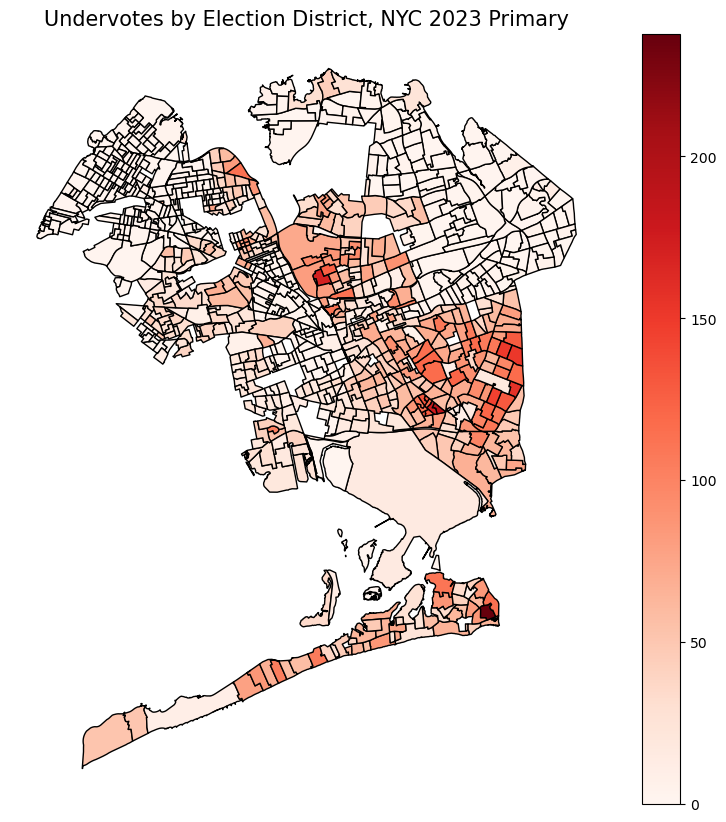

In [25]:
#plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
undervotes_by_electdist_23.plot(ax=ax,
                                column="undervote",
                                legend=True, 
                                cmap="Reds",
                                edgecolor="black")
ax.set_title("Undervotes by Election District, NYC 2023 Primary", fontsize=15)
ax.set_axis_off()
plt.show()

##Overvotes
1. Apply previously defined function to calculate overvotes by election district
2. Visualize with matplotlib
3. Summarize results

In [26]:
overvotes_by_electdist_23 = nyc_2023_primary_df.groupby("ElectDisct")["overvote"].sum().reset_index()


In [27]:
duplicates_by_electdist_23 = nyc_2023_primary_df.groupby("ElectDisct")["duplicate"].sum().reset_index()

##Total ballot errors
1. Sum the number of overvotes and undervotes in each district + any other errors in the dataset
2. Visualize with matplotlib
3. Summarize results

#Part III: Ballot error distribution over time

1. Make three plots side-by-side comparing the rate of total ballot errors in NYC 2021, 2023, & 2025


# Conclusion

#References

Study of the 2024 STV City Council Election
in Portland, Oregon
https://mggg.org/PPM

Voting Error across Multiple Ballot Types: Results from Super Tuesday (2020) Experiments in Four American States
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3697637

Report: Deficiencies in Recent Research on Ranked Choice Voting Ballot Error Rates
https://mathematics-democracy-institute.org/deficiencies-in-recent-research-on-ranked-choice-voting-ballot-error-rates/

Ballot (and Voter) 'Exhaustion' Under Instant Runoff Voting: An Examination of Four Ranked-Choice Elections
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2519723

Is Ranked-Choice Voting Associated With Turnout Across
Race/Ethnic Groups?
https://onlinelibrary.wiley.com/doi/pdf/10.1111/ssqu.70025

Does ranked choice Voting Increase voter turnout and mobilization?
https://www.sciencedirect.com/science/article/pii/S026137942400074X?via%3Dihub

The Impact of Ranked Choice Voting on the
Democratic Primary Elections of 2021
https://www.gc.cuny.edu/sites/default/files/2022-07/CUR-Report-on-RCV-Final.pdf

Ranked choice voting elections benefit candidates and voters of color: 2024 update
https://fairvote.org/report/communities-of-color-2024/?section=executive-summary